# 03 — New Submission Simulation

Generate → insert → rescore → rank → nearest neighbors.

In [1]:
import notebook_lib as nb

nb.setup_path()
base = nb.load_and_score()
updated = nb.simulate_and_rescore(base, count=1)
new_row = updated.iloc[-1]
rank = int(updated['final_score'].rank(ascending=False, method='min')[new_row.name])
print('Policy:', new_row['policy_no'], '| Score:', round(new_row['final_score'], 2), '| Band:', new_row['risk_band'])
print('Peer:', new_row['peer_group'], '| Global rank:', rank, 'of', len(updated))

Policy: SIM-3440F4D5 | Score: 49.66 | Band: Medium
Peer: PA / Non-Admitted / HO / Unknown | Global rank: 51 of 501


Saved: C:\Users\FEDERICO\OneDrive\Escritorio\Vault\DEMOs\metal-peer-risk-scoring\notebooks\reports\figures\03_simulation_rank.png


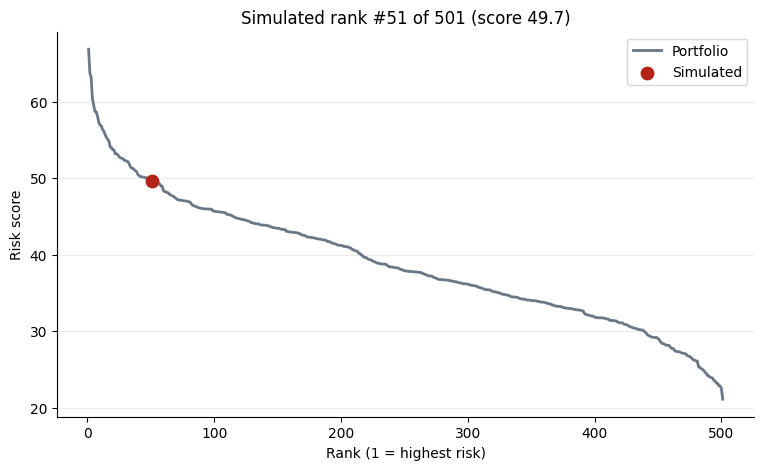

,policy_no,risk_state_cd,final_score,risk_band,similarity
141,HO100208149-03,NY,47.69,Medium,0.870303
489,HO56413533836-07,FL,54.01,High,0.863856
31,HO100042087-06,PA,50.81,High,0.857906
30,HO100042087-05,PA,50.42,High,0.855582
195,HO200030529-02,SC,44.60,Medium,0.854522
109,HO100151163-04,CT,49.43,Medium,0.837518
72,HO100092186-04,NY,38.85,Medium,0.813737
485,HO46134610036-07,FL,50.03,High,0.798859


In [2]:
nb.plot_simulation_context(updated, new_row)
display(nb.nearest_neighbors(updated, new_row['submission_id'], top_k=8)[
    ['policy_no', 'risk_state_cd', 'final_score', 'risk_band', 'similarity']
])